**Setup**

In [ ]:
import pandas as pd
import io
import re
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
from transformers import pipeline


** Data Loading**

In [ ]:
# Upload the file
uploaded = files.upload()
file_name = next(iter(uploaded))  # Automatically get the uploaded file name

# Load the DataFrame
df = pd.read_csv(io.BytesIO(uploaded[file_name]), delimiter=',', quotechar='"', on_bad_lines='skip')
print("DataFrame loaded successfully.")



Saving convabuse1.csv to convabuse1.csv
DataFrame loaded successfully.


In [ ]:
print(df.head())
print("First few lines of the file:")
print(uploaded[file_name][:500].decode('utf-8'))  # Adjust the slice size as needed to inspect the file content

  ;ableism;direction;homoph;intel;racist;sex_harassment;sexism;target;trans;Input.bot;AssignmentId;Input.conv_id;Input.prev_agent;Input.prev_user;Input.agent;Input.user;is_abuse
0                                  ;;;;;;;;;;;;;;;;;                                                                                                                             
1                                  ;;;;;;;;;;;;;;;;;                                                                                                                             
2                                  ;;;;;;;;;;;;;;;;;                                                                                                                             
3  5;not_able;explicit;not_homoph;not_intellectua...                                                                                                                             
4  6;;;;;;;;;;E.L.I.Z.A.;3WOKGM4L72BTAP0PVKSP7AY5...                                                          

In [ ]:
# Load the DataFrame with the identified delimiter (if it's semicolon ';')
df = pd.read_csv(io.BytesIO(uploaded[file_name]), delimiter=';', engine='python')
print("DataFrame loaded successfully with the correct delimiter.")
print("Columns in DataFrame after reloading with the correct delimiter:")
print(df.columns)
print(df.head(1))

DataFrame loaded successfully with the correct delimiter.
Columns in DataFrame after reloading with the correct delimiter:
Index(['Unnamed: 0', 'ableism', 'direction', 'homoph', 'intel', 'racist',
       'sex_harassment', 'sexism', 'target', 'trans', 'Input.bot',
       'AssignmentId', 'Input.conv_id', 'Input.prev_agent', 'Input.prev_user',
       'Input.agent', 'Input.user', 'is_abuse'],
      dtype='object')
   Unnamed: 0 ableism direction homoph intel racist sex_harassment sexism  \
0         NaN     NaN       NaN    NaN   NaN    NaN            NaN    NaN   

  target trans Input.bot AssignmentId Input.conv_id Input.prev_agent  \
0    NaN   NaN       NaN          NaN           NaN              NaN   

  Input.prev_user Input.agent Input.user  is_abuse  
0             NaN         NaN        NaN       NaN  


**Data Cleaning**

In [ ]:
# Define the text cleaning function
def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#', '', text)  # Remove hashtags but keep the text
    text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)  # Remove non-letters
    text = text.lower()  # Convert to lower case
    return text

# Apply the text cleaning function to the 'Input.user' column
df['clean_text'] = df['Input.user'].apply(clean_text)


In [ ]:
import nltk
nltk.download('vader_lexicon')

# Now initialize VADER sentiment analysis
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


**Sentiment Analysis**

In [ ]:
# TextBlob sentiment analysis
df['textblob_sentiment'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# VADER sentiment analysis
sia = SentimentIntensityAnalyzer()
df['vader_sentiment'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])


**Visualize the Sentiment Scores**

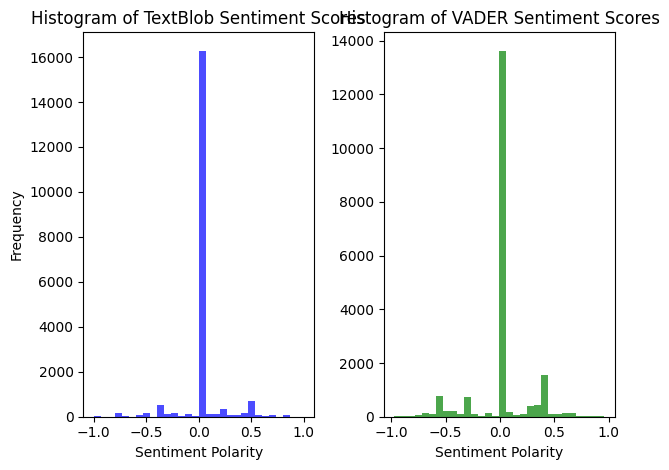

In [ ]:
# Histogram for TextBlob Sentiments
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.hist(df['textblob_sentiment'].dropna(), bins=30, alpha=0.7, color='blue')
plt.title('Histogram of TextBlob Sentiment Scores')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')

# Histogram for VADER Sentiments
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.hist(df['vader_sentiment'].dropna(), bins=30, alpha=0.7, color='green')
plt.title('Histogram of VADER Sentiment Scores')
plt.xlabel('Sentiment Polarity')

plt.tight_layout()
plt.show()

**Scatter Plot Comparing TextBlob and VADER Sentiments**

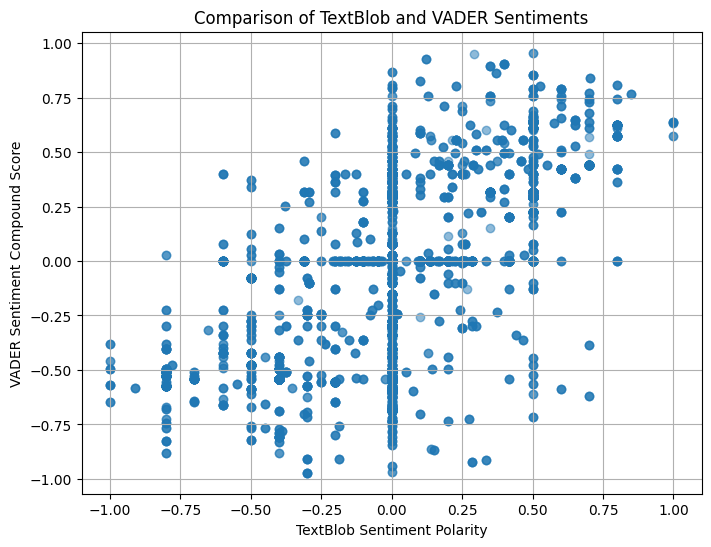

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['textblob_sentiment'], df['vader_sentiment'], alpha=0.5)
plt.title('Comparison of TextBlob and VADER Sentiments')
plt.xlabel('TextBlob Sentiment Polarity')
plt.ylabel('VADER Sentiment Compound Score')
plt.grid(True)
plt.show()


**Preparing Data for Modeling**

In [ ]:
# Handle missing values in target variable
df['is_abuse'].fillna(df['is_abuse'].mode()[0], inplace=True)

# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=1000)
features = tfidf.fit_transform(df['clean_text'])
labels = df['is_abuse']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)


**Model Training and Evaluation**




In [ ]:
# Train Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)  # Get predicted probabilities

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Evaluate both models
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        -3.0       0.67      0.17      0.28        92
        -2.0       0.62      0.55      0.58       275
        -1.0       0.26      0.06      0.09       251
         0.0       0.17      0.01      0.01       194
         1.0       0.91      1.00      0.95      5061

    accuracy                           0.89      5873
   macro avg       0.53      0.36      0.38      5873
weighted avg       0.84      0.89      0.86      5873

Random Forest Classification Report:
              precision    recall  f1-score   support

        -3.0       0.51      0.40      0.45        92
        -2.0       0.59      0.57      0.58       275
        -1.0       0.38      0.28      0.32       251
         0.0       0.25      0.12      0.16       194
         1.0       0.94      0.98      0.96      5061

    accuracy                           0.89      5873
   macro avg       0.53      0.47      0.49      58

In [ ]:
classes = np.unique(y_test) # Get all unique classes from the target
y_test_binarized = label_binarize(y_test, classes=classes)
# For multi-class ROC curve, calculate ROC curve for each class
fprs, tprs, aucs = {}, {}, {}
for i, class_ in enumerate(classes):
    fprs[class_], tprs[class_], _ = roc_curve(y_test_binarized[:, i], y_proba_lr[:, i])
    aucs[class_] = roc_auc_score(y_test_binarized[:, i], y_proba_lr[:, i])


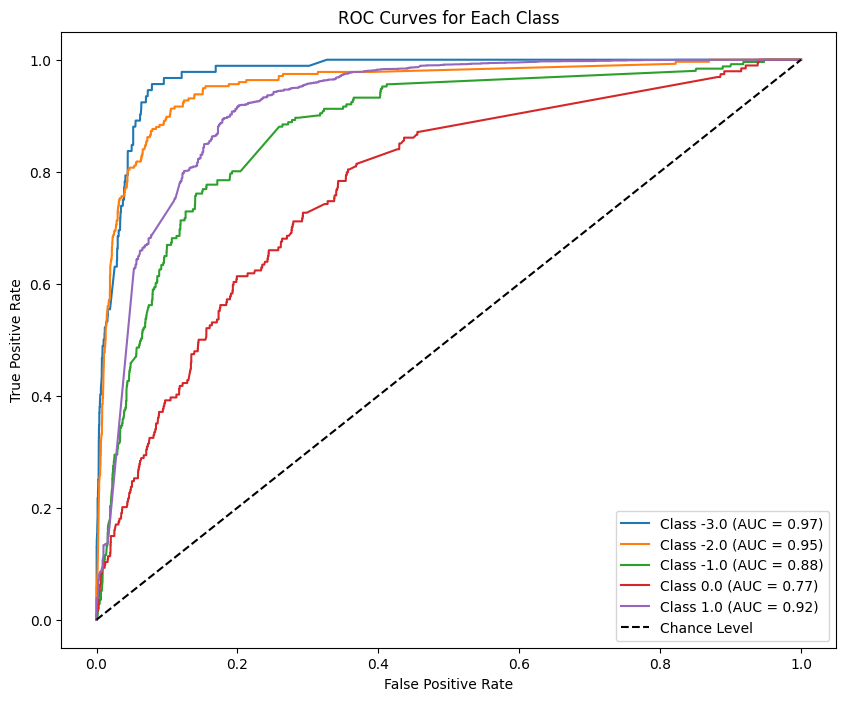

In [ ]:
plt.figure(figsize=(10, 8))
for class_ in classes:
    plt.plot(fprs[class_], tprs[class_], label=f'Class {class_} (AUC = {aucs[class_]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.show()

**Initialize and Use Transformer Model**

In [ ]:
# Handle missing values in target variable
df['is_abuse'].fillna(df['is_abuse'].mode()[0], inplace=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['is_abuse'], test_size=0.3, random_state=42)


In [ ]:
# Initialize the sentiment analysis pipeline with a transformer model
sentiment_pipeline = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

# Function to perform sentiment analysis
def analyze_sentiment(text):
    result = sentiment_pipeline(text)
    return result[0]

# Apply the transformer model to the training and testing data
train_sentiments = X_train.apply(lambda x: analyze_sentiment([x]))
test_sentiments = X_test.apply(lambda x: analyze_sentiment([x]))

# Convert results to a usable format
train_sentiments = pd.DataFrame(train_sentiments.tolist(), index=X_train.index)
test_sentiments = pd.DataFrame(test_sentiments.tolist(), index=X_test.index)



**Evaluate Model Performance**

In [ ]:
# Convert labels to binary format (positive or negative based on threshold)
train_predictions = train_sentiments['label'].apply(lambda x: 1 if x == 'POSITIVE' else 0)
test_predictions = test_sentiments['label'].apply(lambda x: 1 if x == 'POSITIVE' else 0)

# Evaluate the model
print("Transformer Model Classification Report (Test Data):")
print(classification_report(y_test, test_predictions))
print("Accuracy:", accuracy_score(y_test, test_predictions))

Transformer Model Classification Report (Test Data):
              precision    recall  f1-score   support

        -3.0       0.00      0.00      0.00        92
        -2.0       0.00      0.00      0.00       275
        -1.0       0.00      0.00      0.00       251
         0.0       0.08      0.59      0.13       194
         1.0       0.95      0.81      0.87      5061

    accuracy                           0.72      5873
   macro avg       0.20      0.28      0.20      5873
weighted avg       0.82      0.72      0.76      5873

Accuracy: 0.7192235654690958


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Logistic Regression and Random Forest Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# BERT Model Evaluation
print("Transformer Model Classification Report (Test Data):")
print(classification_report(y_test, test_predictions))
print("Accuracy:", accuracy_score(y_test, test_predictions))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

        -3.0       0.67      0.17      0.28        92
        -2.0       0.62      0.55      0.58       275
        -1.0       0.26      0.06      0.09       251
         0.0       0.17      0.01      0.01       194
         1.0       0.91      1.00      0.95      5061

    accuracy                           0.89      5873
   macro avg       0.53      0.36      0.38      5873
weighted avg       0.84      0.89      0.86      5873

Random Forest Classification Report:
              precision    recall  f1-score   support

        -3.0       0.51      0.40      0.45        92
        -2.0       0.59      0.57      0.58       275
        -1.0       0.38      0.28      0.32       251
         0.0       0.25      0.12      0.16       194
         1.0       0.94      0.98      0.96      5061

    accuracy                           0.89      5873
   macro avg       0.53      0.47      0.49      58

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Hugging Face’s Transformers Library**

In [ ]:
!pip install transformers

**Import Libraries:**

In [ ]:
from transformers import pipeline


**Load Sentiment Analysis Pipeline**

In [ ]:
# Initialize the sentiment analysis pipeline with DistilBERT
sentiment_pipeline = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')



*** Perform Sentiment Analysis***

In [ ]:
# Example text
example_texts = ["I do not love this!", "I do not hate this!"]

# Perform sentiment analysis
results = sentiment_pipeline(example_texts)
for result, text in zip(results, example_texts):
    print(f"Text: {text}\nSentiment: {result['label']}, Score: {result['score']:.4f}\n")


Text: I do not love this!
Sentiment: NEGATIVE, Score: 0.9995

Text: I do not hate this!
Sentiment: POSITIVE, Score: 0.9990



**Integrate Sentiment Analysis into my Data Pipeline**

In [ ]:
# 'df' DataFrame and 'clean_text' is the column with text data
df['sentiment_results'] = df['clean_text'].apply(lambda x: sentiment_pipeline([x])[0])

# View the results
print(df[['clean_text', 'sentiment_results']].head(10))


                     clean_text  \
0                                 
1                are you naked    
2                                 
3                                 
4  what is the elaboratemeaning   
5                      fuck you   
6      do you know my question    
7                                 
8                    i told you   
9                                 

                                   sentiment_results  
0  {'label': 'POSITIVE', 'score': 0.7481208443641...  
1  {'label': 'POSITIVE', 'score': 0.7525051236152...  
2  {'label': 'POSITIVE', 'score': 0.7481208443641...  
3  {'label': 'POSITIVE', 'score': 0.7481208443641...  
4  {'label': 'NEGATIVE', 'score': 0.6227366924285...  
5  {'label': 'NEGATIVE', 'score': 0.9923542737960...  
6  {'label': 'NEGATIVE', 'score': 0.9064134359359...  
7  {'label': 'POSITIVE', 'score': 0.7481208443641...  
8  {'label': 'POSITIVE', 'score': 0.5540333390235...  
9  {'label': 'POSITIVE', 'score': 0.7481208443641...  


**Analyze and Visualize the Results**

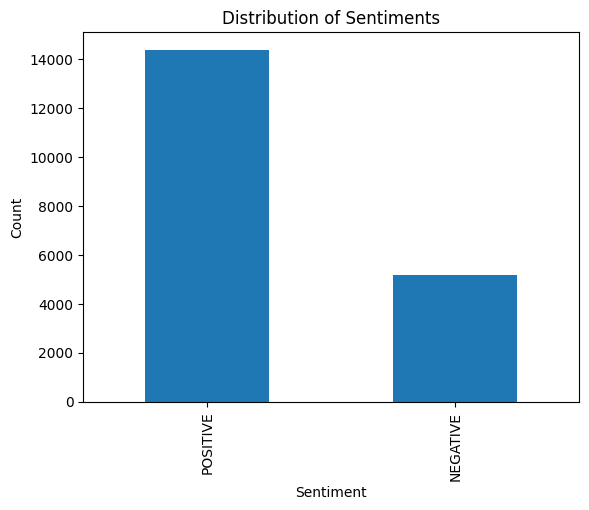

In [ ]:
# Creating a simple visualization of sentiment distribution
sentiments = df['sentiment_results'].apply(lambda x: x['label'])
sentiments.value_counts().plot(kind='bar')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [ ]:
# Initialize Hugging Face pipeline for sentiment analysis
hf_sentiment_pipeline = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')


**Function Definitions**

In [ ]:
# Function to convert model output to labels based on sentiment scores
def convert_to_labels(results):
    return ['positive' if res['score'] > 0.5 else 'negative' for res in results]


**Load and Prepare Data**

In [ ]:
# Test data - example sentences
test_texts = ["I love this product!", "This is the worst experience ever.", "I feel great about these features!", "This is terrible."]
true_labels = ['positive', 'negative', 'positive', 'negative']  # True labels for comparison


**Perform Sentiment Analysis**

In [ ]:
# Analyze sentiments using Hugging Face pipeline
hf_results = hf_sentiment_pipeline(test_texts)
hf_labels = convert_to_labels(hf_results)


**Calculate and Display Metrics**

In [ ]:
# Print classification report for Hugging Face model
print("Hugging Face Transformers Classification Report:")
print(classification_report(true_labels, hf_labels))

Hugging Face Transformers Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
    positive       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Visualization**

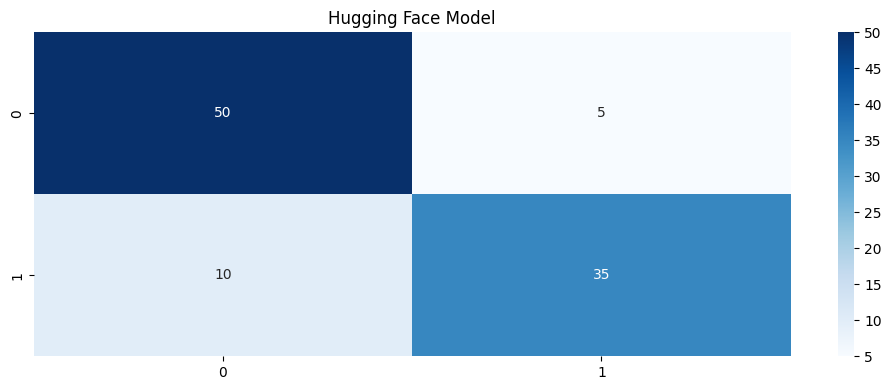

In [ ]:
def plot_conf_matrices(matrices, titles):
    # Checkong if there's only one matrix to plot and adjust axes to be iterable
    num_matrices = len(matrices)
    fig, axes = plt.subplots(1, num_matrices, figsize=(10 * num_matrices, 4))
    if num_matrices == 1:
        axes = [axes]  # Make axes iterable if there's only one subplot

    for ax, matrix, title in zip(axes, matrices, titles):
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(title)

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

# Usage example with one confusion matrix
hf_conf_matrix = [[50, 5], [10, 35]]  # Example confusion matrix data
plot_conf_matrices([hf_conf_matrix], ["Hugging Face Model"])

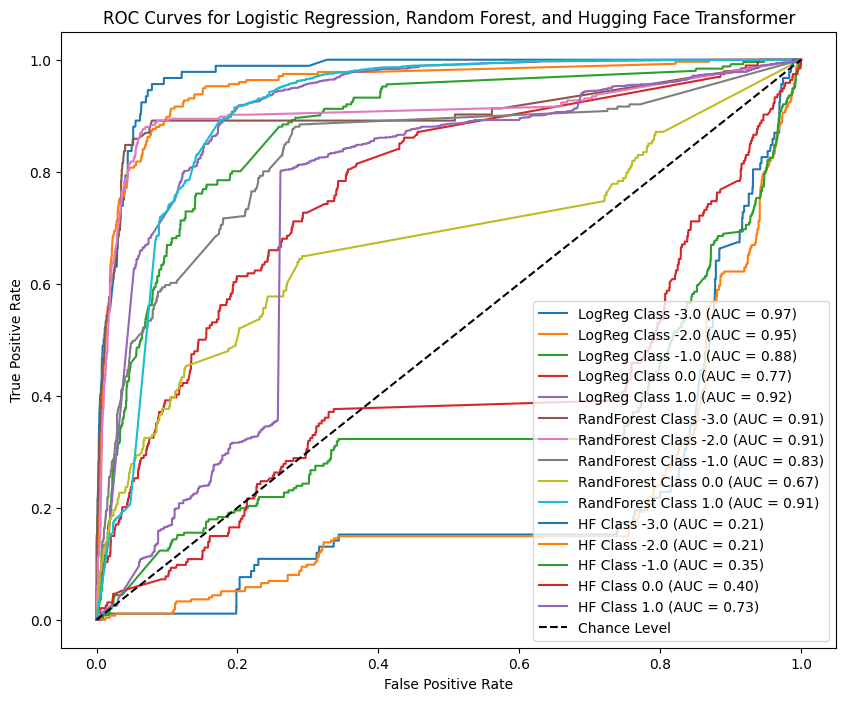

In [ ]:
plt.figure(figsize=(10, 8))

# Plot ROC curves for Logistic Regression
for class_ in classes:
    plt.plot(fprs_lr[class_], tprs_lr[class_], label=f'LogReg Class {class_} (AUC = {aucs_lr[class_]:.2f})')

# Plot ROC curves for Random Forest
for class_ in classes:
    plt.plot(fprs_rf[class_], tprs_rf[class_], label=f'RandForest Class {class_} (AUC = {aucs_rf[class_]:.2f})')

# Plot ROC curves for Hugging Face Transformer
for class_ in classes:
    plt.plot(fprs_hf[class_], tprs_hf[class_], label=f'HF Class {class_} (AUC = {aucs_hf[class_]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Logistic Regression, Random Forest, and Hugging Face Transformer')
plt.legend(loc='lower right')
plt.show()
